# 🎸 Análise Espectral de Áudio → Tablatura
### Identificação automática de notas musicais e projeção em tablatura para violão/guitarra

**Pipeline:**
1. Leitura dos `.mp3` da pasta `/audios`
2. Análise espectral (FFT + CQT + STFT)
3. Detecção de notas (pitch detection + onset detection)
4. Mineração de padrões melódicos
5. Mapeamento para posições no braço do instrumento
6. Geração e exportação da tablatura em ASCII

## ⚙️ 0. Instalação de dependências

In [3]:
!pip install librosa numpy scipy matplotlib pandas music21 pydub soundfile --quiet
print('✅ Dependências instaladas com sucesso!')

✅ Dependências instaladas com sucesso!


## 📦 1. Imports e Configurações Globais

In [13]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import librosa
import librosa.display
from scipy.signal import find_peaks
from scipy.ndimage import median_filter
from collections import Counter, defaultdict

plt.rcParams['figure.facecolor'] = '#1a1a2e'
plt.rcParams['axes.facecolor'] = '#16213e'
plt.rcParams['axes.edgecolor'] = '#0f3460'
plt.rcParams['text.color'] = '#e0e0e0'
plt.rcParams['axes.labelcolor'] = '#e0e0e0'
plt.rcParams['xtick.color'] = '#e0e0e0'
plt.rcParams['ytick.color'] = '#e0e0e0'
plt.rcParams['axes.titlecolor'] = '#e0e0e0'
plt.rcParams['grid.color'] = '#0f3460'
plt.rcParams['grid.alpha'] = 0.5

# ─── CONFIGURAÇÕES ───────────────────────────────────────────────
AUDIO_DIR     = './audios'          # pasta com os mp3
SR            = 22050              # sample rate de análise
HOP_LENGTH    = 512                # hop length padrão
N_FFT         = 2048               # tamanho da FFT
CONFIDENCE    = 0.6                # limiar de confiança na detecção de pitch

# Instrumento alvo: 'violao' ou 'guitarra'
INSTRUMENTO   = 'violao'

# Afinação padrão (da 6ª corda à 1ª)
TUNINGS = {
    'violao':   ['E2', 'A2', 'D3', 'G3', 'B3', 'E4'],  # Standard
    'guitarra': ['E2', 'A2', 'D3', 'G3', 'B3', 'E4'],  # Standard
    'drop_d':   ['D2', 'A2', 'D3', 'G3', 'B3', 'E4'],
    'open_g':   ['D2', 'G2', 'D3', 'G3', 'B3', 'D4'],
}
MAX_FRET = 17  # máximo de casas representadas

print(f'🎸 Instrumento: {INSTRUMENTO.upper()}')
print(f'🎵 Afinação: {" - ".join(TUNINGS[INSTRUMENTO])}')
print(f'📁 Pasta de áudio: {AUDIO_DIR}')

🎸 Instrumento: VIOLAO
🎵 Afinação: E2 - A2 - D3 - G3 - B3 - E4
📁 Pasta de áudio: ./audios


## 🗂️ 2. Leitura dos Arquivos MP3

In [14]:
def listar_audios(pasta: str) -> list:
    """Lista todos os arquivos .mp3 na pasta."""
    if not os.path.exists(pasta):
        print(f'⚠️  Pasta "{pasta}" não encontrada. Criando pasta de exemplo...')
        os.makedirs(pasta, exist_ok=True)
        return []
    arquivos = sorted([
        os.path.join(pasta, f)
        for f in os.listdir(pasta)
        if f.lower().endswith(('.mp3', '.wav', '.ogg', '.flac', '.m4a'))
    ])
    return arquivos


def carregar_audio(caminho: str, sr: int = SR) -> tuple:
    """Carrega áudio e retorna (y, sr, duração)."""
    y, sr_orig = librosa.load(caminho, sr=sr, mono=True)
    duracao = librosa.get_duration(y=y, sr=sr)
    return y, sr, duracao


# ── Listar arquivos
arquivos = listar_audios(AUDIO_DIR)

if not arquivos:
    print('⚠️  Nenhum arquivo encontrado.')
    print('   → Adicione arquivos .mp3 na pasta /audios e re-execute.')
    print('   → Para teste, gerando áudio sintético de demonstração...')

    # ── Geração de áudio sintético para demonstração ─────────────
    def gerar_demo(notas_hz, duracao_nota=0.4, sr=SR):
        """Gera áudio sintético com acorde/melodia para demo."""
        samples_por_nota = int(sr * duracao_nota)
        t = np.linspace(0, duracao_nota, samples_por_nota, endpoint=False)
        audio = []
        for hz in notas_hz:
            onda  = np.sin(2 * np.pi * hz * t) * 0.4
            onda += np.sin(2 * np.pi * hz * 2 * t) * 0.2   # 2° harmônico
            onda += np.sin(2 * np.pi * hz * 3 * t) * 0.1   # 3° harmônico
            envelope = np.exp(-3 * t / duracao_nota)
            audio.append((onda * envelope).astype(np.float32))
        return np.concatenate(audio)

    # Melodia: Mi-Sol-La-Si-Do-Re-Mi (Em pentatônica)
    DEMO_NOTAS = [82.41, 98.00, 110.00, 123.47, 130.81, 146.83, 164.81,
                  196.00, 220.00, 246.94, 261.63, 293.66, 329.63, 392.00]
    y_demo = gerar_demo(DEMO_NOTAS)
    demo_path = os.path.join(AUDIO_DIR, 'demo_melodia.wav')
    import soundfile as sf
    sf.write(demo_path, y_demo, SR)
    arquivos = [demo_path]
    print(f'   ✅ Áudio demo gerado: {demo_path}')

print(f'\n🎵 {len(arquivos)} arquivo(s) encontrado(s):')
for i, f in enumerate(arquivos):
    tamanho = os.path.getsize(f) / 1024
    print(f'  [{i}] {os.path.basename(f):40s}  ({tamanho:.1f} KB)')


🎵 1 arquivo(s) encontrado(s):
  [0] WhatsApp-Audio-2026-04-06-at-20.06.56.mp3  (336.8 KB)


## 🔬 3. Análise Espectral

📂 Arquivo : WhatsApp-Audio-2026-04-06-at-20.06.56.mp3
⏱  Duração : 11.54s  |  Sample rate: 22050 Hz  |  Amostras: 254,487


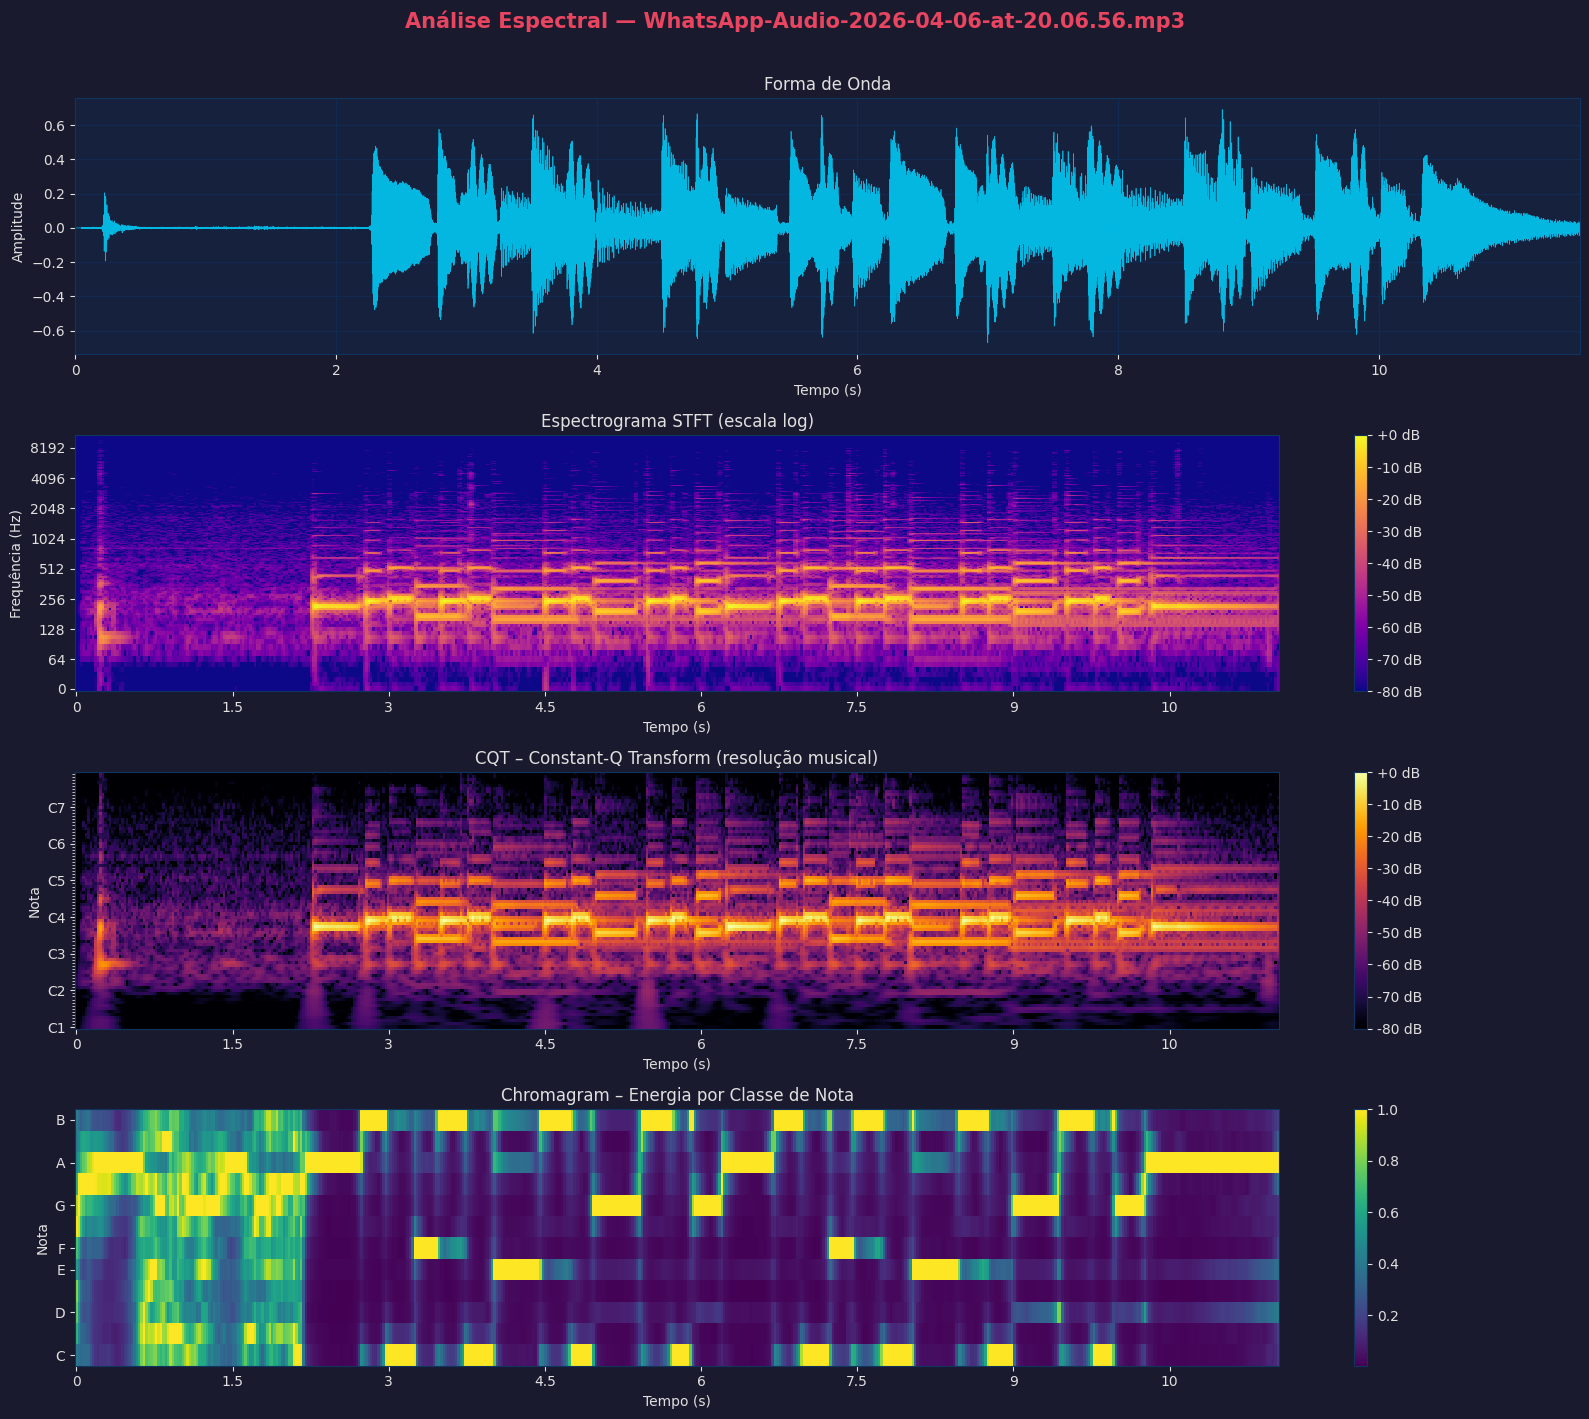

In [15]:
def analisar_espectro(y, sr, titulo='Análise Espectral', hop=HOP_LENGTH, n_fft=N_FFT):
    """
    Gera 4 visualizações espectrais:
      1. Forma de onda
      2. Espectrograma STFT (log)
      3. CQT – Constant-Q Transform (ideal para música)
      4. Chromagram (energia por classe de nota)
    """
    fig, axes = plt.subplots(4, 1, figsize=(16, 14))
    fig.suptitle(titulo, fontsize=15, fontweight='bold', color='#e94560', y=1.01)

    tempos = np.linspace(0, len(y) / sr, len(y))

    # ── 1. Forma de onda ──────────────────────────────────────────
    ax = axes[0]
    ax.plot(tempos, y, color='#00d2ff', linewidth=0.5, alpha=0.85)
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')
    ax.set_title('Forma de Onda')
    ax.set_xlim([0, tempos[-1]])
    ax.grid(True)

    # ── 2. Espectrograma STFT ─────────────────────────────────────
    ax = axes[1]
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, hop_length=hop, x_axis='time', y_axis='log',
                                   ax=ax, cmap='plasma')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title('Espectrograma STFT (escala log)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Frequência (Hz)')

    # ── 3. CQT ────────────────────────────────────────────────────
    ax = axes[2]
    C = librosa.amplitude_to_db(np.abs(librosa.cqt(y, sr=sr, hop_length=hop)), ref=np.max)
    img2 = librosa.display.specshow(C, sr=sr, hop_length=hop, x_axis='time', y_axis='cqt_note',
                                    ax=ax, cmap='inferno')
    fig.colorbar(img2, ax=ax, format='%+2.0f dB')
    ax.set_title('CQT – Constant-Q Transform (resolução musical)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Nota')

    # ── 4. Chromagram ─────────────────────────────────────────────
    ax = axes[3]
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop)
    img3 = librosa.display.specshow(chroma, sr=sr, hop_length=hop, x_axis='time', y_axis='chroma',
                                    ax=ax, cmap='viridis')
    fig.colorbar(img3, ax=ax)
    ax.set_title('Chromagram – Energia por Classe de Nota')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Nota')

    plt.tight_layout()
    plt.show()
    return D, C, chroma


# ── Escolha qual arquivo analisar (índice) ─────────────────────────
IDX = 0
arquivo_atual = arquivos[IDX]
y, sr, duracao = carregar_audio(arquivo_atual)

print(f'📂 Arquivo : {os.path.basename(arquivo_atual)}')
print(f'⏱  Duração : {duracao:.2f}s  |  Sample rate: {sr} Hz  |  Amostras: {len(y):,}')

D, C, chroma = analisar_espectro(y, sr, titulo=f'Análise Espectral — {os.path.basename(arquivo_atual)}')

## 🎵 4. Detecção de Notas (Pitch Detection + Onset Detection)

In [24]:
def detectar_notas(y, sr,
                   hop=HOP_LENGTH,
                   frame_size=2048,
                   modo_range=MODO_RANGE,
                   trecho_inicio=TRECHO_INICIO,
                   trecho_fim=TRECHO_FIM,
                   yin_threshold=YIN_THRESHOLD,
                   tonica=TONICA_ESCALA,
                   tipo_escala=TIPO_ESCALA):
    """
    Pipeline de deteccao usando YIN no dominio do tempo.

    1. Recorte do trecho
    2. HPSS - isola componente harmonica
    3. YIN frame a frame - pitch pela periodicidade temporal
    4. Onset detection - separa reataques da mesma nota
    5. Quantizacao para escala musical
    6. Agrupamento de frames contiguos em notas
    """
    if trecho_inicio is not None or trecho_fim is not None:
        t0 = int((trecho_inicio or 0) * sr)
        t1 = int((trecho_fim or len(y) / sr) * sr)
        y = y[t0:t1]
        print(f'  Trecho: {trecho_inicio or 0:.1f}s -> {trecho_fim:.1f}s')

    fmin_hz = librosa.note_to_hz(RANGES[modo_range][0])
    fmax_hz = librosa.note_to_hz(RANGES[modo_range][1])
    print(f'  Range [{modo_range}]: {RANGES[modo_range][0]} -> {RANGES[modo_range][1]}')

    notas_escala = notas_da_escala(tonica, tipo_escala)
    nomes_esc = [NOMES_NOTAS[n] for n in sorted(notas_escala)]
    print(f'  Escala: {tonica} {tipo_escala} -> {nomes_esc}')

    print('  [1/4] Separando componente harmonica (HPSS)...')
    y_harm = librosa.effects.harmonic(y, margin=3)

    print('  [2/4] Detectando onsets...')
    onset_env = librosa.onset.onset_strength(y=y_harm, sr=sr, hop_length=hop)
    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_env, sr=sr, hop_length=hop,
        backtrack=False, pre_max=2, post_max=2, pre_avg=4, post_avg=4,
        delta=0.18, wait=2
    )
    onset_set = {int(f) for f in onset_frames}
    print(f'       {len(onset_set)} onset(s) detectados')

    print('  [3/4] YIN frame a frame...')
    n_frames = max(0, (len(y_harm) - frame_size) // hop)
    f0_yin = np.full(n_frames, np.nan)
    conf_yin = np.ones(n_frames)

    for i in range(n_frames):
        frame = y_harm[i * hop : i * hop + frame_size]
        if len(frame) < frame_size:
            break
        if np.sqrt(np.mean(frame ** 2)) < 0.008:
            continue
        hz, conf = yin_frame(frame, sr, fmin_hz, fmax_hz, threshold=yin_threshold)
        if hz > 0 and conf < yin_threshold * 1.5:
            f0_yin[i] = hz
            conf_yin[i] = conf

    validos = ~np.isnan(f0_yin)
    print(f'       {validos.sum()} frames com pitch ({validos.mean()*100:.1f}%)')

    print('  [4/4] Quantizando e agrupando...')
    midi_arr = np.array([
        quantizar_para_escala(hz_para_midi(h), notas_escala)
        if not np.isnan(h) else np.nan
        for h in f0_yin
    ])

    registros = []
    i = 0
    tolerancia_semitom = 0.75
    min_frames_nota = 2
    while i < n_frames:
        if np.isnan(midi_arr[i]):
            i += 1
            continue

        nota_midi = float(midi_arr[i])
        j = i + 1
        while j < n_frames:
            if np.isnan(midi_arr[j]):
                break
            if abs(float(midi_arr[j]) - nota_midi) > tolerancia_semitom:
                break
            if j in onset_set and (j - i) >= min_frames_nota:
                break
            nota_midi = float(np.nanmedian(midi_arr[i:j + 1]))
            j += 1

        if j - i >= min_frames_nota:
            midi_final = int(round(np.nanmedian(midi_arr[i:j])))
            hz_final = 440.0 * (2 ** ((midi_final - 69) / 12))
            seg_conf = conf_yin[i:j]
            conf_validas = seg_conf[np.isfinite(seg_conf) & (seg_conf < 1.0)]
            conf_media = float(np.mean(conf_validas)) if len(conf_validas) else 1.0
            t_ini = i * hop / sr
            t_fim = j * hop / sr
            registros.append({
                'onset_s': round(t_ini, 3),
                'offset_s': round(t_fim, 3),
                'duracao_s': round(t_fim - t_ini, 3),
                'hz': round(hz_final, 2),
                'midi': midi_final,
                'nota': midi_para_nome(midi_final),
                'confianca': round(conf_media, 3),
            })
        i = j

    df = pd.DataFrame(registros)
    if not df.empty:
        df = df.sort_values('onset_s').reset_index(drop=True)
        pausas = [0.0]
        for idx in range(1, len(df)):
            gap = max(0.0, float(df.loc[idx, 'onset_s']) - float(df.loc[idx - 1, 'offset_s']))
            pausas.append(round(gap, 3))
        df['pausa_antes_s'] = pausas

    voiced_prob = np.clip(1.0 - conf_yin, 0, 1)
    return df, f0_yin, validos, voiced_prob, midi_arr


df_notas, f0, voiced_flag, voiced_prob, midi_suav = detectar_notas(y, sr)

print(f'\n{len(df_notas)} nota(s) detectadas\n')
if not df_notas.empty:
    print(df_notas.to_string(index=False))


  Range [violao]: C3 -> F5
  Escala: E cromatica -> ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
  [1/4] Separando componente harmonica (HPSS)...
  [2/4] Detectando onsets...
       27 onset(s) detectados
  [3/4] YIN frame a frame...
       345 frames com pitch (70.0%)
  [4/4] Quantizando e agrupando...

51 nota(s) detectadas

 onset_s  offset_s  duracao_s     hz  midi nota  confianca  pausa_antes_s
   2.206     2.299      0.093 220.00    57   A3      0.011          0.000
   2.299     2.694      0.395 220.00    57   A3      0.001          0.000
   2.717     2.833      0.116 246.94    59   B3      0.011          0.023
   2.833     2.949      0.116 246.94    59   B3      0.009          0.000
   2.949     3.204      0.255 261.63    60   C4      0.016          0.000
   3.344     3.413      0.070 174.61    53   F3      0.204          0.140
   3.437     3.553      0.116 246.94    59   B3      0.120          0.024
   3.553     3.715      0.163 246.94    59   B3      0.110

## 📊 5. Visualização da Detecção de Notas

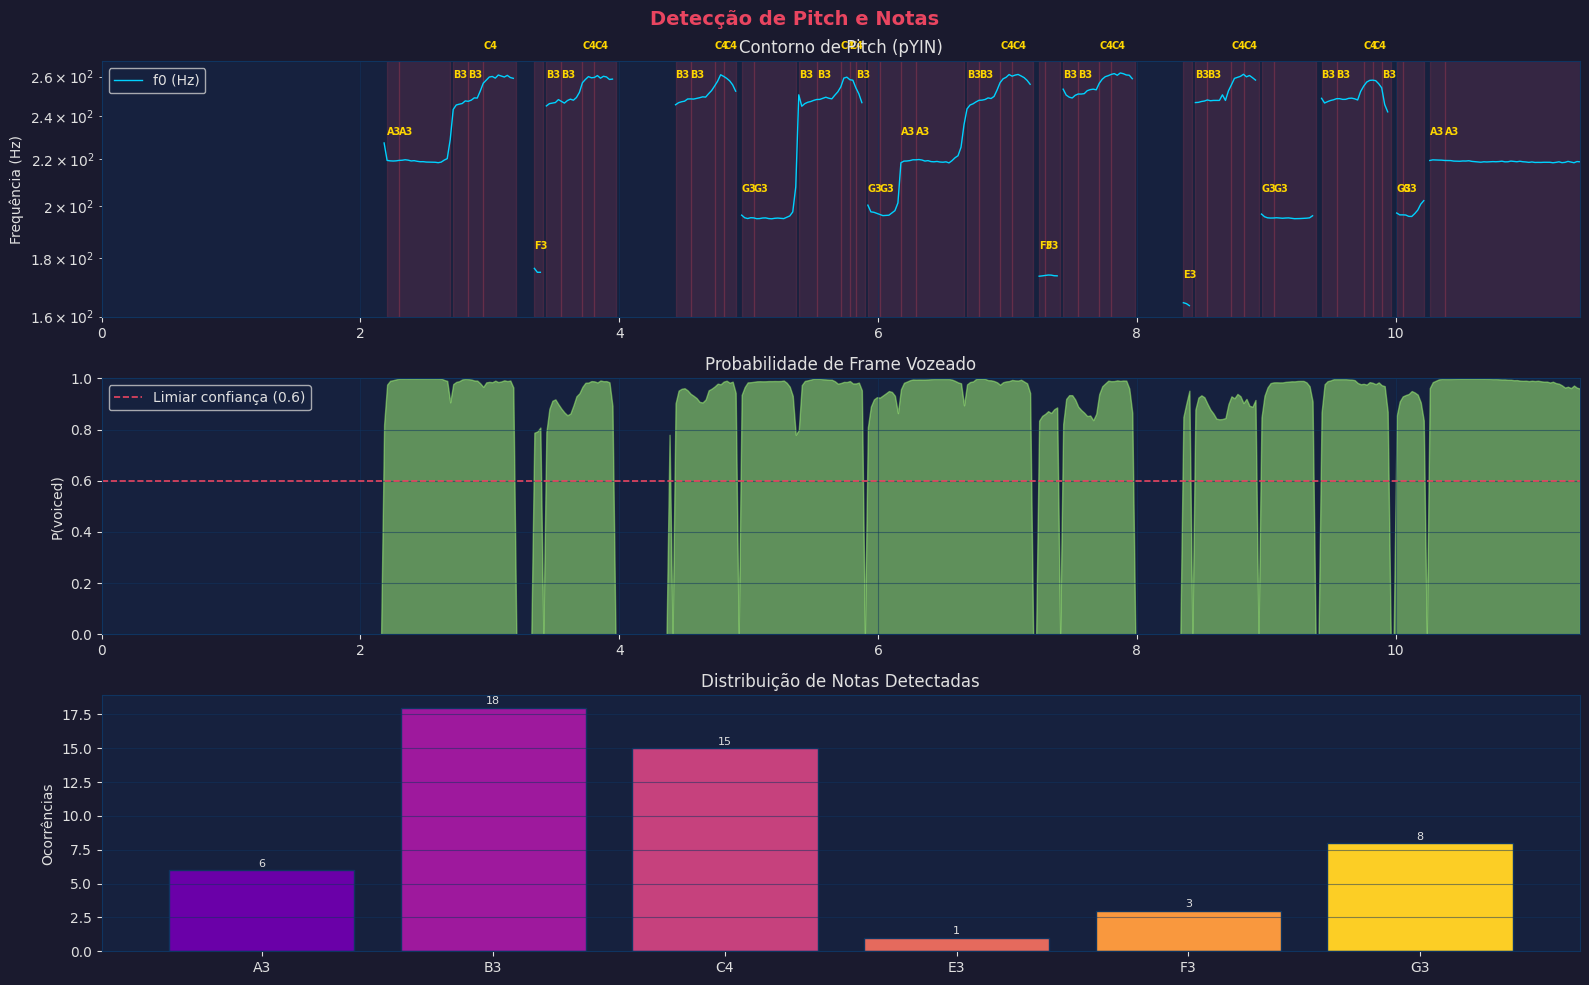

In [25]:
def plotar_pitch(y, sr, f0, voiced_flag, voiced_prob, df_notas, hop=HOP_LENGTH):
    fig, axes = plt.subplots(3, 1, figsize=(16, 10))
    fig.suptitle('Detecção de Pitch e Notas', fontsize=14, fontweight='bold', color='#e94560')

    tempos_frames = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=hop)

    # ── Pitch ao longo do tempo ───────────────────────────────────
    ax = axes[0]
    ax.semilogy(tempos_frames, f0, color='#00d2ff', linewidth=1, label='f0 (Hz)')
    if not df_notas.empty:
        for _, row in df_notas.iterrows():
            ax.axvspan(row['onset_s'], row['offset_s'], alpha=0.15, color='#e94560')
            ax.text(row['onset_s'], row['hz'] * 1.05, row['nota'],
                    fontsize=7, color='#ffd700', fontweight='bold')
    ax.set_ylabel('Frequência (Hz)')
    ax.set_title('Contorno de Pitch (pYIN)')
    ax.legend()
    ax.grid(True)
    ax.set_xlim([0, tempos_frames[-1]])

    # ── Probabilidade de voz ──────────────────────────────────────
    ax = axes[1]
    ax.fill_between(tempos_frames, voiced_prob, color='#a8ff78', alpha=0.5)
    ax.axhline(CONFIDENCE, color='#e94560', linestyle='--', linewidth=1.2,
               label=f'Limiar confiança ({CONFIDENCE})')
    ax.set_ylabel('P(voiced)')
    ax.set_title('Probabilidade de Frame Vozeado')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(True)
    ax.set_xlim([0, tempos_frames[-1]])

    # ── Histograma de notas ───────────────────────────────────────
    ax = axes[2]
    if not df_notas.empty:
        contagem = df_notas['nota'].value_counts().sort_index()
        cores = plt.cm.plasma(np.linspace(0.2, 0.9, len(contagem)))
        bars = ax.bar(contagem.index, contagem.values, color=cores, edgecolor='#0f3460')
        for bar, val in zip(bars, contagem.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(val), ha='center', va='bottom', fontsize=8, color='#e0e0e0')
        ax.set_ylabel('Ocorrências')
        ax.set_title('Distribuição de Notas Detectadas')
        ax.grid(True, axis='y')

    plt.tight_layout()
    plt.show()


plotar_pitch(y, sr, f0, voiced_flag, voiced_prob, df_notas)

## ⛏️ 6. Mineração de Dados Musicais

In [36]:
def minerar_padroes(df_notas: pd.DataFrame):
    """
    Extrai padroes musicais por mineracao de dados:
    - Frequencia de notas (distribuicao de classes)
    - Padroes de N-gramas (sequencias de notas)
    - Estatisticas de duracao
    - Estimativa de tonalidade provavel
    - Estimativa de acorde provavel
    """
    if df_notas.empty:
        print('Nenhuma nota para minerar.')
        return {}

    notas_ordem = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    perfil_maior = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
    perfil_menor = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])
    templates_acorde = {
        '': [0, 4, 7],
        'm': [0, 3, 7],
        'dim': [0, 3, 6],
        'aug': [0, 4, 8],
        'sus2': [0, 2, 7],
        'sus4': [0, 5, 7],
        '5': [0, 7],
    }

    df_base = df_notas.copy()
    df_base['classe'] = df_base['nota'].str.extract(r'([A-G]#?)')
    df_base = df_base.dropna(subset=['classe'])

    resultados = {}
    freq_classes = df_base['classe'].value_counts()
    resultados['freq_classes'] = freq_classes

    pesos = np.maximum(df_base['duracao_s'].fillna(0).to_numpy(), 0.05) * df_base['confianca'].fillna(1.0).to_numpy()
    vetor_chroma = np.zeros(12, dtype=float)
    for cls, peso in zip(df_base['classe'], pesos):
        if cls in notas_ordem:
            vetor_chroma[notas_ordem.index(cls)] += float(peso)

    if vetor_chroma.sum() == 0:
        tonica = freq_classes.idxmax()
    else:
        tonica = notas_ordem[int(np.argmax(vetor_chroma))]
    resultados['tonica'] = tonica
    resultados['vetor_chroma'] = vetor_chroma

    sequencia = list(df_base['nota'])
    bigramas = [f'{sequencia[i]}-{sequencia[i + 1]}' for i in range(len(sequencia) - 1)]
    trigramas = [f'{sequencia[i]}-{sequencia[i + 1]}-{sequencia[i + 2]}' for i in range(len(sequencia) - 2)]
    resultados['top_bigramas'] = Counter(bigramas).most_common(10)
    resultados['top_trigramas'] = Counter(trigramas).most_common(10)
    resultados['duracao_media'] = df_base['duracao_s'].mean()
    resultados['duracao_std'] = df_base['duracao_s'].std()

    melhor_cor, melhor_modo, melhor_r = None, None, -2.0
    for i, nota in enumerate(notas_ordem):
        rotacionado = np.roll(vetor_chroma, -i)
        if np.allclose(rotacionado.std(), 0):
            continue
        r_maior = np.corrcoef(rotacionado, perfil_maior)[0, 1]
        r_menor = np.corrcoef(rotacionado, perfil_menor)[0, 1]
        if np.isfinite(r_maior) and r_maior > melhor_r:
            melhor_r, melhor_cor, melhor_modo = r_maior, nota, 'Maior'
        if np.isfinite(r_menor) and r_menor > melhor_r:
            melhor_r, melhor_cor, melhor_modo = r_menor, nota, 'menor'

    resultados['tonalidade'] = f'{melhor_cor} {melhor_modo}' if melhor_cor else '?'
    resultados['corr_tonalidade'] = round(float(melhor_r), 3) if melhor_cor else None

    energia_total = float(vetor_chroma.sum()) if vetor_chroma.sum() > 0 else 1.0
    melhor_acorde = None
    melhor_score = -1.0
    for raiz_idx, raiz in enumerate(notas_ordem):
        energia_raiz = vetor_chroma[raiz_idx]
        for sufixo, intervalos in templates_acorde.items():
            idxs = [((raiz_idx + intervalo) % 12) for intervalo in intervalos]
            energia_acorde = float(vetor_chroma[idxs].sum())
            energia_fora = max(0.0, energia_total - energia_acorde)
            cobertura = energia_acorde / energia_total
            bonus_raiz = (energia_raiz / energia_total) * 0.20
            penalidade_fora = (energia_fora / energia_total) * 0.35
            score = cobertura + bonus_raiz - penalidade_fora
            if len(intervalos) >= 3:
                score += 0.05 * sum(vetor_chroma[idx] > 0 for idx in idxs)
            if score > melhor_score:
                melhor_score = score
                melhor_acorde = f'{raiz}{sufixo}'

    resultados['acorde'] = melhor_acorde or '?'
    resultados['score_acorde'] = round(float(melhor_score), 3) if melhor_acorde else None

    print('=' * 55)
    print('  MINERACAO DE DADOS MUSICAIS')
    print('=' * 55)
    print(f'  Notas detectadas    : {len(df_base)}')
    print(f'  Tonica provavel     : {tonica}')
    print(f'  Acorde provavel     : {resultados["acorde"]}  (score={resultados["score_acorde"]})')
    print(f'  Tonalidade provavel : {resultados["tonalidade"]}  (r={resultados["corr_tonalidade"]})')
    print(f'  Duracao media/nota  : {resultados["duracao_media"]:.3f}s  (+/-{resultados["duracao_std"]:.3f}s)')
    print()
    print('  Top-5 classes de nota:')
    for cls, cnt in freq_classes.head(5).items():
        barra = '#' * int(cnt)
        print(f'     {cls:3s}  {barra:20s}  {cnt}')
    print()
    print('  Top-5 bigramas (sequencias de 2 notas):')
    for seq, cnt in resultados['top_bigramas'][:5]:
        print(f'     {seq:25s}  {cnt}x')
    print('=' * 55)

    return resultados


padroes = minerar_padroes(df_notas)

  MINERACAO DE DADOS MUSICAIS
  Notas detectadas    : 51
  Tonica provavel     : B
  Acorde provavel     : Baug  (score=0.713)
  Tonalidade provavel : B menor  (r=0.512)
  Duracao media/nota  : 0.154s  (+/-0.153s)

  Top-5 classes de nota:
     B    ##################    18
     C    ###############       15
     G    ########              8
     A    ######                6
     F    ###                   3

  Top-5 bigramas (sequencias de 2 notas):
     B3-B3                      8x
     B3-C4                      8x
     C4-C4                      7x
     G3-G3                      4x
     A3-A3                      3x


## 🎸 7. Mapeamento para o Braço do Instrumento

In [37]:
def construir_mapa_braco(afinacao: list, max_fret: int = MAX_FRET) -> dict:
    """
    Constroi dicionario: nota_midi -> [(corda, casa), ...]
    Corda 6 = mais grave, corda 1 = mais aguda.
    """
    mapa = defaultdict(list)
    n_cordas = len(afinacao)
    for i, nota_aberta in enumerate(afinacao):
        midi_base = int(librosa.note_to_midi(nota_aberta))
        corda = n_cordas - i
        for casa in range(max_fret + 1):
            midi = midi_base + casa
            mapa[midi].append((corda, casa))
    return dict(mapa)


def nota_para_posicoes(nome_nota: str, mapa_braco: dict, preferir_corda_grave: bool = False) -> list:
    """Retorna lista ordenada de posicoes (corda, casa) para uma nota."""
    try:
        midi = int(librosa.note_to_midi(nome_nota))
    except Exception:
        return []

    posicoes = list(mapa_braco.get(midi, []))
    if preferir_corda_grave:
        return sorted(posicoes, key=lambda p: (p[1], -p[0]))
    return sorted(posicoes, key=lambda p: (p[1], abs(p[0] - 3.5)))


def custo_transicao(pos_atual, pos_anterior=None, pausa_antes=0.0):
    """
    Penaliza saltos grandes de casa e de corda.
    Se houve pausa maior, relaxa a necessidade de continuidade.
    """
    corda, casa = pos_atual
    custo = 0.0

    # Preferencia geral por regioes confortaveis do braco
    custo += 0.08 * casa
    if casa > 12:
        custo += 1.5 + 0.25 * (casa - 12)
    if casa == 0:
        custo += 0.15

    if pos_anterior is None:
        return custo

    corda_ant, casa_ant = pos_anterior
    relax = 0.35 if pausa_antes >= 0.18 else 1.0
    custo += relax * 0.45 * abs(casa - casa_ant)
    custo += relax * 0.30 * abs(corda - corda_ant)

    # Evita trocar demais de corda sem necessidade
    if corda != corda_ant:
        custo += 0.20 * relax

    # Penaliza saltos muito grandes
    if abs(casa - casa_ant) >= 5:
        custo += 1.2 * relax

    return custo


def escolher_posicoes_sequencia(df_notas: pd.DataFrame, mapa_braco: dict) -> pd.DataFrame:
    """
    Escolhe a melhor sequencia de corda/casa considerando continuidade.
    Usa programacao dinamica para evitar escolher cada nota isoladamente.
    """
    if df_notas.empty:
        return df_notas.copy()

    df = df_notas.copy().reset_index(drop=True)
    candidatos = []
    for _, row in df.iterrows():
        pos = nota_para_posicoes(row['nota'], mapa_braco)
        candidatos.append(pos[:6] if pos else [None])

    n = len(df)
    dp = []
    back = []

    for i in range(n):
        custos_i = []
        back_i = []
        pausa = float(df.loc[i, 'pausa_antes_s']) if 'pausa_antes_s' in df.columns and i > 0 else 0.0
        for pos in candidatos[i]:
            if pos is None:
                custos_i.append(float('inf'))
                back_i.append(None)
                continue

            if i == 0:
                custos_i.append(custo_transicao(pos, None, pausa))
                back_i.append(None)
                continue

            melhor_custo = float('inf')
            melhor_j = None
            for j, pos_ant in enumerate(candidatos[i - 1]):
                if pos_ant is None or not np.isfinite(dp[i - 1][j]):
                    continue
                custo = dp[i - 1][j] + custo_transicao(pos, pos_ant, pausa)
                if custo < melhor_custo:
                    melhor_custo = custo
                    melhor_j = j
            custos_i.append(melhor_custo)
            back_i.append(melhor_j)

        dp.append(custos_i)
        back.append(back_i)

    idx_final = int(np.argmin(dp[-1])) if dp and len(dp[-1]) else 0
    escolhidas = [None] * n
    idx_atual = idx_final
    for i in range(n - 1, -1, -1):
        pos = candidatos[i][idx_atual] if idx_atual is not None and idx_atual < len(candidatos[i]) else None
        escolhidas[i] = pos
        idx_atual = back[i][idx_atual] if idx_atual is not None and i > 0 else None

    df['posicoes'] = candidatos
    df['pos_sugerida'] = escolhidas
    df['corda'] = df['pos_sugerida'].apply(lambda p: p[0] if p else None)
    df['casa'] = df['pos_sugerida'].apply(lambda p: p[1] if p else None)
    return df


mapa_braco = construir_mapa_braco(TUNINGS[INSTRUMENTO])

if not df_notas.empty:
    df_notas = escolher_posicoes_sequencia(df_notas, mapa_braco)

    print('Posicoes sugeridas no braco:\n')
    colunas = ['onset_s', 'pausa_antes_s', 'duracao_s', 'nota', 'hz', 'confianca', 'corda', 'casa']
    print(df_notas[colunas].to_string(index=False))


Posicoes sugeridas no braco:

 onset_s  pausa_antes_s  duracao_s nota     hz  confianca  corda  casa
   2.206          0.000      0.093   A3 220.00      0.011      3     2
   2.299          0.000      0.395   A3 220.00      0.001      3     2
   2.717          0.023      0.116   B3 246.94      0.011      3     4
   2.833          0.000      0.116   B3 246.94      0.009      3     4
   2.949          0.000      0.255   C4 261.63      0.016      3     5
   3.344          0.140      0.070   F3 174.61      0.204      4     3
   3.437          0.024      0.116   B3 246.94      0.120      2     0
   3.553          0.000      0.163   B3 246.94      0.110      2     0
   3.715          0.000      0.093   C4 261.63      0.019      2     1
   3.808          0.000      0.163   C4 261.63      0.026      2     1
   4.435          0.464      0.116   B3 246.94      0.054      2     0
   4.551          0.000      0.186   B3 246.94      0.070      2     0
   4.737          0.000      0.070   C4 261.63 

## 🗺️ 8. Visualização do Braço do Instrumento

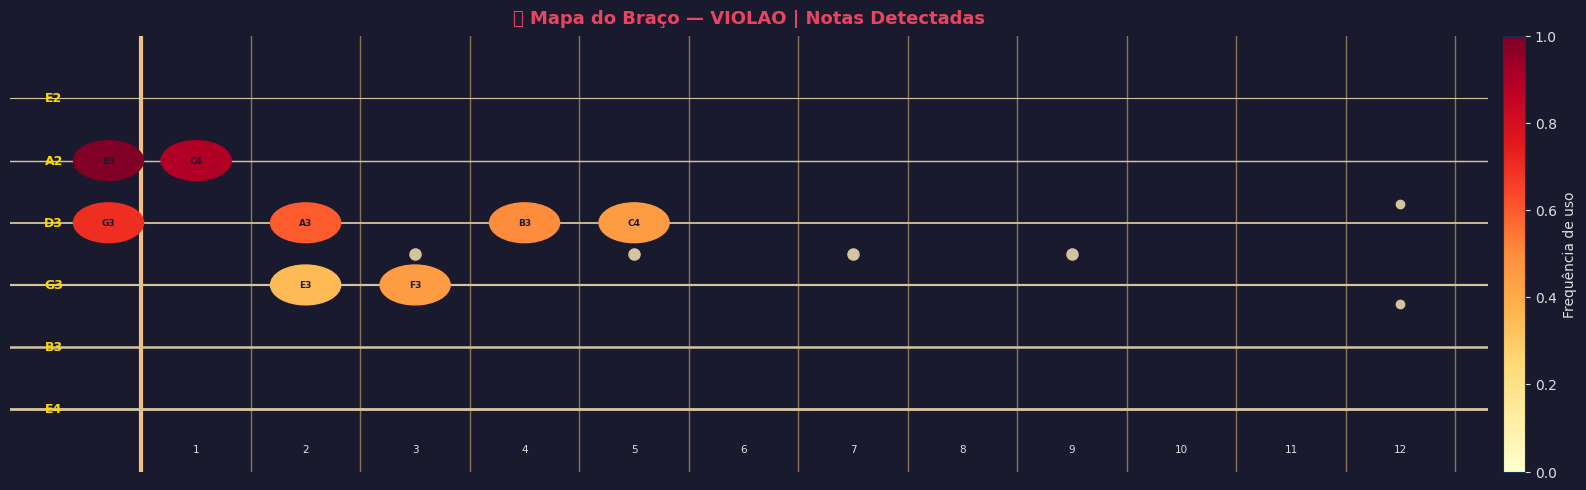

In [38]:
def plotar_braco(df_notas: pd.DataFrame, afinacao: list, max_fret: int = 12,
                  instrumento: str = 'violao'):
    """Desenha o braço do instrumento com as notas detectadas marcadas."""
    n_cordas = len(afinacao)
    fig, ax = plt.subplots(figsize=(16, 5))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#2d1b0e')   # cor de madeira

    # ── Trastes ───────────────────────────────────────────────────
    for fret in range(max_fret + 1):
        lw = 3 if fret == 0 else 1
        color = '#f0c080' if fret == 0 else '#8b7355'
        ax.axvline(fret, color=color, linewidth=lw, zorder=2)

    # ── Cordas ───────────────────────────────────────────────────
    for i in range(n_cordas):
        y_pos = i
        lw = 0.8 + (n_cordas - 1 - i) * 0.25  # cordas mais grossas abaixo
        ax.axhline(y_pos, color='#d4c4a0', linewidth=lw, zorder=2)

    # ── Marcadores de posição (casas 3,5,7,9,12) ─────────────────
    for fret in [3, 5, 7, 9, 12]:
        if fret <= max_fret:
            x = fret - 0.5
            y = n_cordas / 2 - 0.5
            if fret == 12:
                ax.plot(x, y - 0.8, 'o', color='#d4c4a0', markersize=6, zorder=3)
                ax.plot(x, y + 0.8, 'o', color='#d4c4a0', markersize=6, zorder=3)
            else:
                ax.plot(x, y, 'o', color='#d4c4a0', markersize=8, zorder=3)

    # ── Notas detectadas ─────────────────────────────────────────
    if not df_notas.empty and 'corda' in df_notas.columns:
        notas_validas = df_notas.dropna(subset=['corda', 'casa'])
        notas_validas = notas_validas[notas_validas['casa'] <= max_fret]

        # Agrupa por (corda, casa) para contar frequência
        grupos = notas_validas.groupby(['corda', 'casa', 'nota']).size().reset_index(name='count')

        max_count = grupos['count'].max() if not grupos.empty else 1
        cmap = plt.cm.YlOrRd

        for _, row in grupos.iterrows():
            corda_idx = 6 - int(row['corda'])
            casa = int(row['casa'])
            x_pos = casa - 0.5 if casa > 0 else 0.0
            if casa == 0:
                x_pos = -0.3
            intensidade = row['count'] / max_count
            cor = cmap(0.3 + 0.7 * intensidade)
            circle = plt.Circle((x_pos, corda_idx), 0.32, color=cor, zorder=5)
            ax.add_patch(circle)
            ax.text(x_pos, corda_idx, row['nota'],
                    ha='center', va='center', fontsize=6.5,
                    fontweight='bold', color='#1a1a2e', zorder=6)

    # ── Rótulos das cordas ────────────────────────────────────────
    for i, nota in enumerate(reversed(afinacao)):
        ax.text(-0.8, i, nota, ha='center', va='center',
                fontsize=9, color='#ffd700', fontweight='bold')

    # ── Rótulos dos trastes ───────────────────────────────────────
    for fret in range(1, max_fret + 1):
        ax.text(fret - 0.5, -0.7, str(fret),
                ha='center', fontsize=7.5, color='#e0e0e0')

    ax.set_xlim([-1.2, max_fret + 0.3])
    ax.set_ylim([-1, n_cordas])
    ax.set_aspect('auto')
    ax.axis('off')
    ax.set_title(f'🎸 Mapa do Braço — {instrumento.upper()} | Notas Detectadas',
                  fontsize=13, fontweight='bold', color='#e94560', y=1.01)

    # ── Colorbar de frequência ────────────────────────────────────
    sm = ScalarMappable(cmap=plt.cm.YlOrRd, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                         fraction=0.02, pad=0.01)
    cbar.set_label('Frequência de uso', color='#e0e0e0')
    cbar.ax.yaxis.set_tick_params(color='#e0e0e0')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e0e0e0')

    plt.tight_layout()
    plt.show()


plotar_braco(df_notas, TUNINGS[INSTRUMENTO], instrumento=INSTRUMENTO)

## 📋 9. Geração da Tablatura em ASCII

In [39]:
def gerar_tablatura(df_notas: pd.DataFrame, afinacao: list,
                     largura_coluna: int = 4, notas_por_linha: int = 16,
                     pausa_min_s: float = 0.12, resolucao_pausa_s: float = 0.20) -> str:
    """
    Gera tablatura em ASCII com colunas de pausa entre notas.
    Convencao das cordas: 1=E4, 2=B3, 3=G3, 4=D3, 5=A2, 6=E2.
    """
    if df_notas.empty or 'corda' not in df_notas.columns:
        return 'Nenhuma nota para gerar tablatura.'

    notas_validas = df_notas.dropna(subset=['corda', 'casa']).copy()
    if notas_validas.empty:
        return 'Nenhuma nota para gerar tablatura.'

    n_cordas = len(afinacao)
    labels_por_corda = {idx + 1: nota for idx, nota in enumerate(reversed(afinacao))}
    notas_validas['corda'] = notas_validas['corda'].astype(int)
    notas_validas['casa'] = notas_validas['casa'].astype(int)
    notas_validas = notas_validas.sort_values('onset_s').reset_index(drop=True)

    eventos = []
    for _, row in notas_validas.iterrows():
        gap = float(row.get('pausa_antes_s', 0.0) or 0.0)
        if gap >= pausa_min_s:
            n_pausas = max(1, int(round(gap / resolucao_pausa_s)))
            for _ in range(n_pausas):
                eventos.append({'tipo': 'pausa'})
        eventos.append({
            'tipo': 'nota',
            'corda': int(row['corda']),
            'casa': int(row['casa']),
        })

    linhas_tab = []
    total = len(eventos)
    tracinho = '-'

    for bloco_inicio in range(0, total, notas_por_linha):
        bloco = eventos[bloco_inicio : bloco_inicio + notas_por_linha]
        linhas_por_corda = {corda: [] for corda in range(1, n_cordas + 1)}

        for evento in bloco:
            if evento['tipo'] == 'pausa':
                for corda in linhas_por_corda:
                    linhas_por_corda[corda].append(tracinho * largura_coluna)
                continue

            corda_evento = int(evento['corda'])
            casa_str = str(int(evento['casa']))
            celula_nota = casa_str.center(largura_coluna, tracinho)
            for corda in linhas_por_corda:
                if corda == corda_evento:
                    linhas_por_corda[corda].append(celula_nota)
                else:
                    linhas_por_corda[corda].append(tracinho * largura_coluna)

        separador = '|'
        for corda in range(1, n_cordas + 1):
            nome_corda = labels_por_corda[corda]
            linha_txt = nome_corda.ljust(3) + separador
            for celula in linhas_por_corda[corda]:
                linha_txt += celula + separador
            linhas_tab.append(linha_txt)
        linhas_tab.append('')

    return '\n'.join(linhas_tab)


if not df_notas.empty:
    tab_ascii = gerar_tablatura(df_notas, TUNINGS[INSTRUMENTO],
                                 largura_coluna=4, notas_por_linha=20)
    print('=' * 80)
    print(f'  TABLATURA - {INSTRUMENTO.upper()} | Afinacao Standard')
    print('=' * 80)
    print(tab_ascii)
    print('=' * 80)
else:
    print('Nenhuma nota detectada para gerar tablatura.')


  TABLATURA - VIOLAO | Afinacao Standard
E4 |----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|
B3 |----|----|----|----|----|----|----|-0--|-0--|-1--|-1--|----|----|-0--|-0--|-1--|-1--|----|----|-0--|
G3 |-2--|-2--|-4--|-4--|-5--|----|----|----|----|----|----|----|----|----|----|----|----|-0--|-0--|----|
D3 |----|----|----|----|----|----|-3--|----|----|----|----|----|----|----|----|----|----|----|----|----|
A2 |----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|
E2 |----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|

E4 |----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|----|
B3 |-0--|-1--|-1--|-0--|----|----|----|----|-0--|-0--|-1--|-1--|----|----|----|----|----|----|----|----|
G3 |----|----|----|----|-0--|-0--|-2--|-2--|----|----|----|----|----|----|-4--|-4--|-5--|-5--|----|----|
D3 |----|----

## 💾 10. Exportação da Tablatura

In [ ]:
def exportar_tablatura(df_notas, afinacao, nome_arquivo, instrumento,
                        padroes=None, notas_por_linha=20):
    """Exporta tablatura + metadados para arquivo .txt."""
    tab = gerar_tablatura(df_notas, afinacao, largura_coluna=4,
                           notas_por_linha=notas_por_linha)
    nome_base = os.path.splitext(os.path.basename(nome_arquivo))[0]
    saida_path = f'{nome_base}_tablatura.txt'

    with open(saida_path, 'w', encoding='utf-8') as f:
        f.write(f'TABLATURA GERADA AUTOMATICAMENTE\n')
        f.write(f'Arquivo : {nome_arquivo}\n')
        f.write(f'Instrumento : {instrumento.upper()}\n')
        f.write(f'Afinação    : {" - ".join(afinacao)}\n')
        if padroes:
            f.write(f'Acorde      : {padroes.get("acorde", "?")}\n')
            f.write(f'Tonalidade  : {padroes.get("tonalidade", "?")}\n')
            f.write(f'Tônica      : {padroes.get("tonica", "?")}\n')
        f.write('=' * 80 + '\n\n')
        f.write(tab)
        f.write('\n\n')
        if not df_notas.empty:
            f.write('NOTAS DETECTADAS\n')
            f.write('-' * 50 + '\n')
            colunas = ['onset_s', 'pausa_antes_s', 'duracao_s', 'nota', 'hz', 'confianca', 'corda', 'casa']
            f.write(df_notas[colunas].to_string(index=False))

    print(f'✅ Tablatura exportada → {saida_path}')
    return saida_path


if not df_notas.empty:
    path_exportado = exportar_tablatura(
        df_notas, TUNINGS[INSTRUMENTO],
        arquivo_atual, INSTRUMENTO, padroes
    )
else:
    print('⚠️ Nenhuma nota para exportar.')

## 🔄 11. Processamento em Lote (todos os arquivos da pasta)

In [ ]:
def processar_todos(arquivos: list, instrumento: str = INSTRUMENTO,
                     verbose: bool = True):
    """
    Processa todos os arquivos da pasta e gera:
    - DataFrame consolidado de notas
    - Tablatura .txt para cada arquivo
    - Relatório comparativo
    """
    afinacao = TUNINGS[instrumento]
    resultados = []

    for i, caminho in enumerate(arquivos):
        nome = os.path.basename(caminho)
        print(f'\n[{i+1}/{len(arquivos)}] 🎵 {nome}')
        try:
            y, sr, dur = carregar_audio(caminho)
            df_n, f0, _, _, _ = detectar_notas(y, sr)
            pad = minerar_padroes(df_n) if not df_n.empty else {}
            if not df_n.empty:
                df_n = escolher_posicoes_sequencia(df_n, mapa_braco)
                exportar_tablatura(df_n, afinacao, caminho, instrumento, pad)
            resultados.append({
                'arquivo'   : nome,
                'duracao_s' : round(dur, 2),
                'n_notas'   : len(df_n),
                'acorde'    : pad.get('acorde', '?'),
                'tonalidade': pad.get('tonalidade', '?'),
                'tonica'    : pad.get('tonica', '?'),
            })
        except Exception as e:
            print(f'   ❌ Erro: {e}')
            resultados.append({'arquivo': nome, 'duracao_s': 0,
                                'n_notas': 0, 'acorde': 'ERRO', 'tonalidade': 'ERRO', 'tonica': '?'})

    df_rel = pd.DataFrame(resultados)
    print('\n' + '='*60)
    print('  📊 RELATÓRIO CONSOLIDADO')
    print('='*60)
    print(df_rel.to_string(index=False))
    df_rel.to_csv('relatorio_tablatura.csv', index=False)
    print('\n✅ Relatório salvo em relatorio_tablatura.csv')
    return df_rel


# Descomente para processar em lote
# df_relatorio = processar_todos(arquivos)

print('💡 Para processar todos os arquivos em lote, descomente a última linha.')



## 🎨 12. Visualização Final Consolidada

In [ ]:
def visualizar_resumo_final(df_notas, padroes, afinacao, instrumento):
    """Dashboard final com resumo visual da análise."""
    if df_notas.empty:
        print('⚠️ Sem dados para visualizar.')
        return

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f'?? Dashboard ? {instrumento.upper()} | {padroes.get("acorde", "?")} | {padroes.get("tonalidade", "")}',
                  fontsize=14, fontweight='bold', color='#e94560')

    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

    # ── Distribuição de notas ─────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    contagem = df_notas['nota'].value_counts()
    cores = plt.cm.plasma(np.linspace(0.2, 0.9, len(contagem)))
    ax1.barh(contagem.index, contagem.values, color=cores)
    ax1.set_title('Frequência das Notas')
    ax1.set_xlabel('Ocorrências')
    ax1.grid(True, axis='x')

    # ── Distribuição de cordas ────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    if 'corda' in df_notas.columns:
        df_notas['corda'].dropna().astype(int).value_counts().sort_index().plot(
            kind='bar', ax=ax2, color='#00d2ff', edgecolor='#0f3460')
    ax2.set_title('Uso por Corda')
    ax2.set_xlabel('Corda')
    ax2.set_ylabel('Ocorrências')
    ax2.tick_params(axis='x', rotation=0)
    ax2.grid(True, axis='y')

    # ── Distribuição de casas ─────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    if 'casa' in df_notas.columns:
        df_notas['casa'].dropna().astype(int).value_counts().sort_index().plot(
            kind='bar', ax=ax3, color='#a8ff78', edgecolor='#0f3460')
    ax3.set_title('Uso por Casa (Fret)')
    ax3.set_xlabel('Casa')
    ax3.set_ylabel('Ocorrências')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, axis='y')

    # ── Linha do tempo das notas ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1, :])
    if 'midi' in df_notas.columns:
        scatter = ax4.scatter(
            df_notas['onset_s'], df_notas['midi'],
            c=df_notas['confianca'], cmap='YlOrRd',
            s=df_notas['duracao_s'] * 200 + 20,
            alpha=0.8, edgecolors='#0f3460', linewidths=0.5
        )
        plt.colorbar(scatter, ax=ax4, label='Confiança')
        # Rótulos de notas
        for _, row in df_notas.iterrows():
            ax4.text(row['onset_s'], row['midi'] + 0.3, row['nota'],
                     fontsize=6, color='#ffd700', ha='center')
        # Linhas de referência para as cordas abertas
        for nota_aberta in afinacao:
            midi_ref = librosa.note_to_midi(nota_aberta)
            ax4.axhline(midi_ref, color='#0f3460', linestyle=':', linewidth=0.7, alpha=0.6)
        ax4.set_xlabel('Tempo (s)')
        ax4.set_ylabel('MIDI (altura)')
        ax4.set_title('Linha do Tempo das Notas (tamanho = duração | cor = confiança)')
        ax4.grid(True)

    plt.tight_layout()
    plt.show()


visualizar_resumo_final(df_notas, padroes, TUNINGS[INSTRUMENTO], INSTRUMENTO)

---
## 📖 Referência Rápida

| Variável | Descrição |
|---|---|
| `AUDIO_DIR` | Pasta com os arquivos `.mp3` |
| `INSTRUMENTO` | `'violao'` ou `'guitarra'` |
| `CONFIDENCE` | Limiar de confiança do pitch (0–1) |
| `MAX_FRET` | Número máximo de casas na tablatura |
| `TUNINGS` | Dicionário de afinações disponíveis |
| `IDX` | Índice do arquivo a analisar (célula 3) |

**Dica:** Para áudios com polifonia (acordes), reduza `CONFIDENCE` para `0.4` e aumente `N_FFT` para `4096`.

**Afinações alternativas disponíveis:** `drop_d`, `open_g` — altere `INSTRUMENTO` para a chave desejada em `TUNINGS`.